In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import utils
import h5py
import astropy.constants as cons
from matplotlib.colors import LogNorm
import astropy.units as u
import athena_read as ar
import plot_slice
import tde_unit as tde
import pandas as pd
import k3d
from k3d.colormaps import matplotlib_color_maps
import spectrum as sp
from matplotlib.patches import Circle
c=cons.c.cgs.value
G=cons.G.cgs.value
h=cons.h.cgs.value
hbar=h/(2*np.pi)
Msun=cons.M_sun.cgs.value
Mbh=3.0e6*Msun
mp=cons.m_p.cgs.value
me=cons.m_e.cgs.value
kB=cons.k_B.cgs.value
v0=0.0005*c 
mu=0.6
T0=v0**2*mu*mp #temperature unit
rho0=2*G*Mbh/c**2
e= 4.80320425e-10


In [ ]:
leftside = pd.read_csv('../debugOutput/4610_geodesic_r5_plane.csv')
rightside = pd.read_csv('../debugOutput/4610_geodesic_r1_plane.csv')

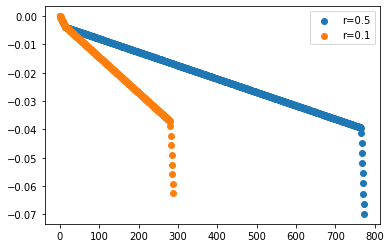

In [8]:
plt.scatter(leftside['n'],leftside['x1'],label='r=0.5')
plt.scatter(rightside['n'],rightside['x1'],label='r=0.1')
plt.legend()
plt.show()

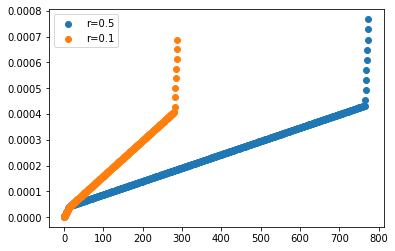

In [9]:
plt.scatter(leftside['n'],leftside['x2'],label='r=0.5')
plt.scatter(rightside['n'],rightside['x2'],label='r=0.1')
plt.legend()
plt.show()

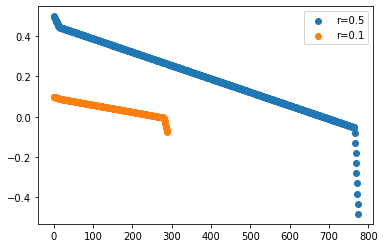

In [10]:
plt.scatter(leftside['n'],leftside['x3'],label='r=0.5')
plt.scatter(rightside['n'],rightside['x3'],label='r=0.1')
plt.legend()
plt.show()

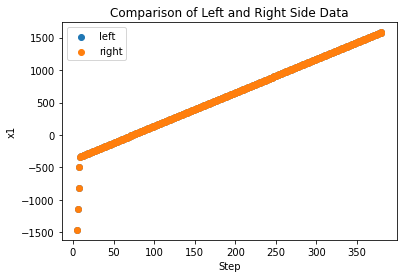

In [3]:
plt.scatter(leftside['step'],leftside['x1'],label='left')
plt.scatter(rightside['step'],rightside['x1'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('x1')
plt.title('Comparison of Left and Right Side Data')
plt.show()

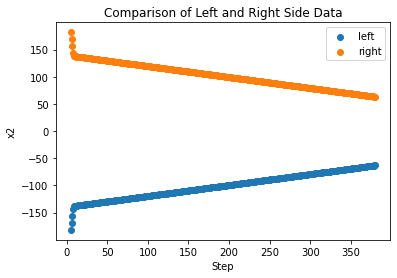

In [4]:
plt.scatter(leftside['step'],leftside['x2'],label='left')
plt.scatter(rightside['step'],rightside['x2'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('x2')
plt.title('Comparison of Left and Right Side Data')
plt.show()

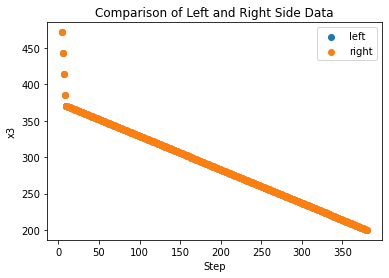

In [5]:
plt.scatter(leftside['step'],leftside['x3'],label='left')
plt.scatter(rightside['step'],rightside['x3'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('x3')
plt.title('Comparison of Left and Right Side Data')
plt.show()

In [6]:
leftside['r'] = np.sqrt(leftside['x1']**2 + leftside['x2']**2 + leftside['x3']**2)
rightside['r'] = np.sqrt(rightside['x1']**2 + rightside['x2']**2 + rightside['x3']**2)
leftside['theta'] = np.arccos(leftside['x3']/leftside['r'])
rightside['theta'] = np.arccos(rightside['x3']/rightside['r'])
leftside['phi'] = np.arctan2(leftside['x2'], leftside['x1'])
rightside['phi'] = np.arctan2(rightside['x2'], rightside['x1'])

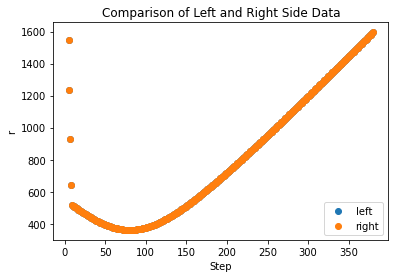

In [7]:
plt.scatter(leftside['step'],leftside['r'],label='left')
plt.scatter(rightside['step'],rightside['r'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('r')
plt.title('Comparison of Left and Right Side Data')
plt.show()

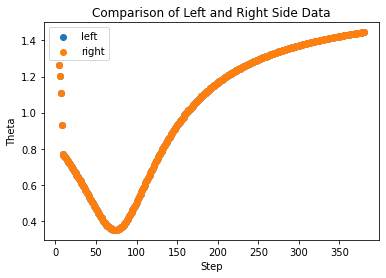

In [8]:
plt.scatter(leftside['step'],leftside['theta'],label='left')
plt.scatter(rightside['step'],rightside['theta'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('Theta')
plt.title('Comparison of Left and Right Side Data')
plt.show()

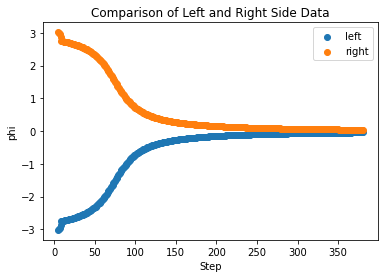

In [9]:
plt.scatter(leftside['step'],leftside['phi'],label='left')
plt.scatter(rightside['step'],rightside['phi'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('phi')
plt.title('Comparison of Left and Right Side Data')
plt.show()

leftside |x1| goes from 1.7689 to 3191.52   |x2| goes from 0.312261 to 245.885 |x3| goes from 0.0197 to 70.399


rightside |x1| goes from 1.11 to 3191.52 |x2| goes from 0.35 to 278.6  |x3| goes from 0.037 to 70.3716  

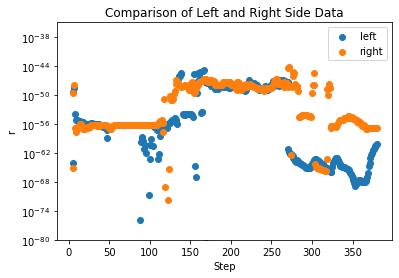

In [11]:

plt.scatter(leftside['step'],leftside['j'],label='left')
plt.scatter(rightside['step'],rightside['j'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('r')
plt.yscale('log')
plt.ylim(1e-80,1e-35)
plt.title('Comparison of Left and Right Side Data')
plt.show()

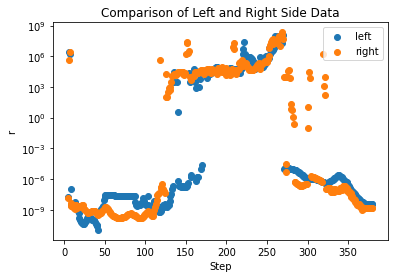

In [12]:
plt.scatter(leftside['step'],leftside['alpha'],label='left')
plt.scatter(rightside['step'],rightside['alpha'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('r')

plt.yscale('log')
plt.title('Comparison of Left and Right Side Data')
plt.show()

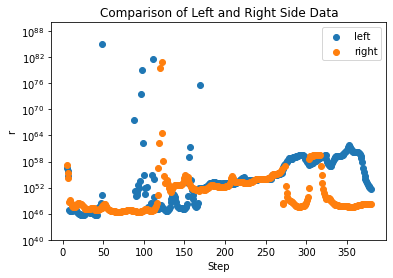

In [13]:
plt.scatter(leftside['step'],leftside['alpha']/leftside['j'],label='left')
plt.scatter(rightside['step'],rightside['alpha']/rightside['j'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('r')

plt.yscale('log')
plt.ylim(1e40,1e90)
plt.title('Comparison of Left and Right Side Data')
plt.show()

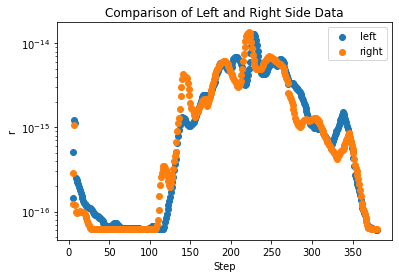

In [14]:
plt.scatter(leftside['step'],leftside['rho'],label='left')
plt.scatter(rightside['step'],rightside['rho'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('r')
plt.yscale('log')
plt.title('Comparison of Left and Right Side Data')
plt.show()

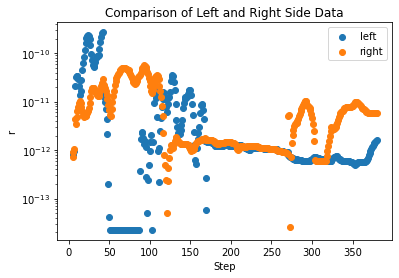

In [15]:
plt.scatter(leftside['step'],leftside['temp'],label='left')
plt.scatter(rightside['step'],rightside['temp'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('r')
plt.yscale('log')
plt.title('Comparison of Left and Right Side Data')
plt.show()

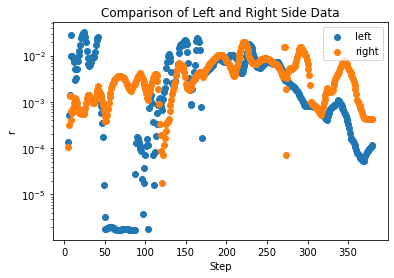

In [16]:
plt.scatter(leftside['step'],leftside['p'],label='left')
plt.scatter(rightside['step'],rightside['p'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('r')
plt.yscale('log')
plt.title('Comparison of Left and Right Side Data')
plt.show()

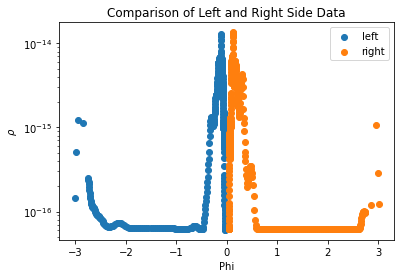

In [17]:
plt.scatter(leftside['phi'],leftside['rho'],label='left')
plt.scatter(rightside['phi'],rightside['rho'],label='right')
plt.legend()
plt.xlabel('Phi')
plt.ylabel('$\\rho$')
plt.yscale('log')
plt.title('Comparison of Left and Right Side Data')
plt.show()

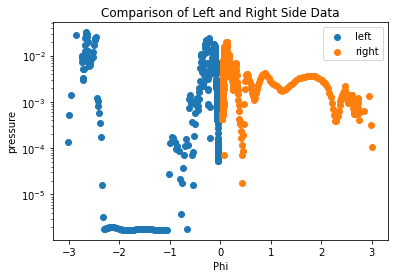

In [18]:
plt.scatter(leftside['phi'],leftside['p'],label='left')
plt.scatter(rightside['phi'],rightside['p'],label='right')
plt.legend()
plt.xlabel('Phi')
plt.ylabel('pressure')
plt.yscale('log')
plt.title('Comparison of Left and Right Side Data')
plt.show()

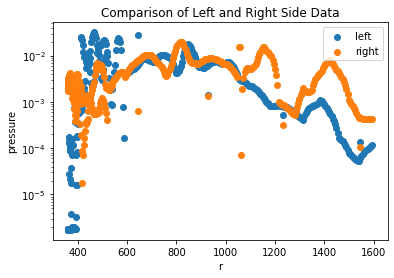

In [19]:
plt.scatter(leftside['r'],leftside['p'],label='left')
plt.scatter(rightside['r'],rightside['p'],label='right')
plt.legend()
plt.xlabel('r')
plt.ylabel('pressure')
plt.yscale('log')
plt.title('Comparison of Left and Right Side Data')
plt.show()

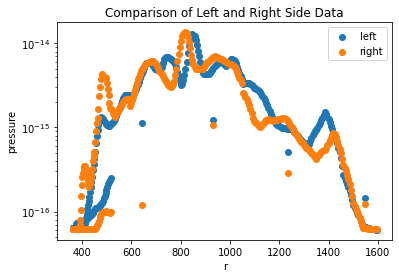

In [20]:
plt.scatter(leftside['r'],leftside['rho'],label='left')
plt.scatter(rightside['r'],rightside['rho'],label='right')
plt.legend()
plt.xlabel('r')
plt.ylabel('pressure')
plt.yscale('log')
plt.title('Comparison of Left and Right Side Data')
plt.show()

In [21]:
leftI = pd.read_csv('../debugOutput/geoEmission6568.csv')
rightI = pd.read_csv('../debugOutput/geoEmission6583.csv')

In [29]:
leftI['r'] = np.sqrt(leftI['x1']**2 + leftI['x2']**2 + leftI['x3']**2)
rightI['r'] = np.sqrt(rightI['x1']**2 + rightI['x2']**2 + rightI['x3']**2)
leftI['theta'] = np.arccos(leftI['x3']/leftI['r'])
rightI['theta'] = np.arccos(rightI['x3']/rightI['r'])
leftI['phi'] = np.arctan2(leftI['x2'], leftI['x1'])
rightI['phi'] = np.arctan2(rightI['x2'], rightI['x1'])

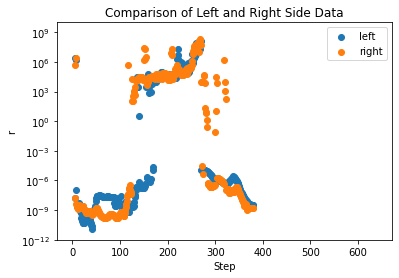

In [22]:
plt.scatter(leftI['step'],leftI['alpha'],label='left')
plt.scatter(rightI['step'],rightI['alpha'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('r')

plt.yscale('log')
plt.ylim(1e-12,1e10)
plt.title('Comparison of Left and Right Side Data')
plt.show()

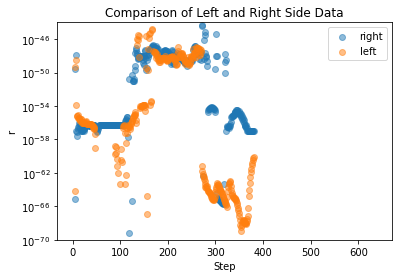

In [92]:

plt.scatter(rightI['step'],rightI['j'],label='right',alpha=0.5)
plt.scatter(leftI['step'],leftI['j'],label='left',alpha=0.5)
plt.legend()
plt.xlabel('Step')
plt.ylabel('r')

plt.yscale('log')
plt.ylim(1e-70,1e-44)
plt.title('Comparison of Left and Right Side Data')
plt.show()

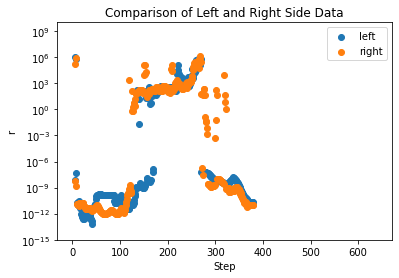

In [24]:
plt.scatter(leftI['step'],leftI['tau'],label='left')
plt.scatter(rightI['step'],rightI['tau'],label='right')
plt.legend()
plt.xlabel('Step')
plt.ylabel('r')

plt.yscale('log')
plt.ylim(1e-15,1e10)
plt.title('Comparison of Left and Right Side Data')
plt.show()

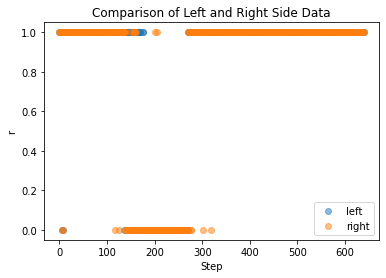

In [94]:
plt.scatter(leftI['step'],leftI['thin'],label='left',alpha=0.5)
plt.scatter(rightI['step'],rightI['thin'],label='right',alpha=0.5)
plt.legend()
plt.xlabel('Step')
plt.ylabel('r')
plt.title('Comparison of Left and Right Side Data')
plt.show()

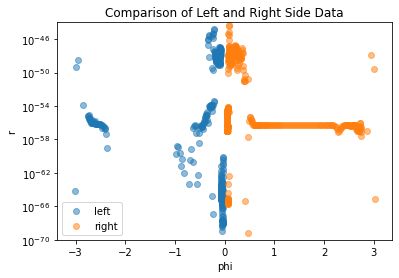

In [93]:
plt.scatter(leftI['phi'],leftI['j'],label='left',alpha=0.5)
plt.scatter(rightI['phi'],rightI['j'],label='right',alpha=0.5)

plt.legend()
plt.xlabel('phi')
plt.ylabel('r')

plt.yscale('log')
plt.ylim(1e-70,1e-44)
plt.title('Comparison of Left and Right Side Data')
plt.show()

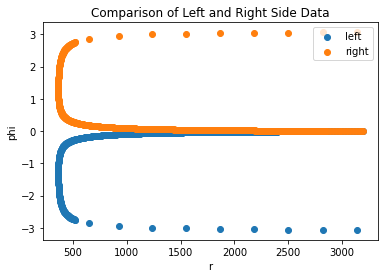

In [46]:
plt.scatter(leftI['r'],leftI['phi'],label='left')
plt.scatter(rightI['r'],rightI['phi'],label='right')

plt.legend()
plt.xlabel('r')
plt.ylabel('phi')

plt.title('Comparison of Left and Right Side Data')
plt.show()

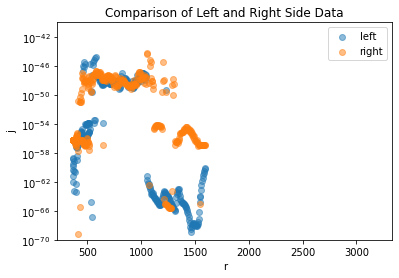

In [49]:
plt.scatter(leftI['r'],leftI['j'],label='left',alpha=0.5)
plt.scatter(rightI['r'],rightI['j'],label='right',alpha=0.5)

plt.legend()
plt.xlabel('r')
plt.ylabel('j')

plt.yscale('log')
plt.ylim(1e-70,1e-40)
plt.title('Comparison of Left and Right Side Data')
plt.show()

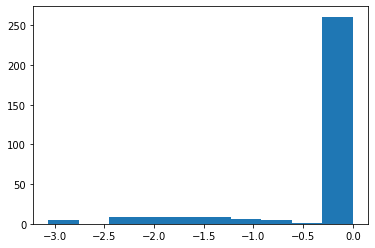

In [40]:
plt.hist(leftI[leftI['j']<1e-70]['phi'])
plt.show()

In [90]:
rightI[rightI['j']<1e-70]

,step,x1,x2,x3,j,alpha,tau,thin,r,theta,phi
0,0,-3070.35,244.498000,614.8040,0.0,0.0,0.0,1,3140.829883,1.373779,3.062128
1,1,-2748.64,231.953000,586.1230,0.0,0.0,0.0,1,2819.993655,1.361424,3.057404
2,2,-2426.92,219.407000,557.4420,0.0,0.0,0.0,1,2499.764329,1.345908,3.051432
3,3,-2105.21,206.862000,528.7620,0.0,0.0,0.0,1,2180.433508,1.325851,3.043645
4,4,-1783.50,194.316000,500.0810,0.0,0.0,0.0,1,1862.447842,1.298953,3.033069
...,...,...,...,...,...,...,...,...,...,...,...
635,635,3101.31,3.829500,64.6024,0.0,0.0,0.0,1,3101.985147,1.549969,0.001235
636,636,3127.85,2.794500,62.2363,0.0,0.0,0.0,1,3128.470359,1.550901,0.000893
637,637,3154.39,1.759500,59.8702,0.0,0.0,0.0,1,3154.958607,1.551819,0.000558
638,638,3175.63,0.931499,57.9772,0.0,0.0,0.0,1,3176.159335,1.552541,0.000293


In [38]:
leftI[leftI['j']<1e-70]

,step,x1,x2,x3,j,alpha,tau,thin,r,theta,phi
0,0,-3070.35,-244.498000,614.8040,0.0,0.0,0.0,1,3140.829883,1.373779,-3.062128
1,1,-2748.64,-231.953000,586.1230,0.0,0.0,0.0,1,2819.993655,1.361424,-3.057404
2,2,-2426.92,-219.407000,557.4420,0.0,0.0,0.0,1,2499.764329,1.345908,-3.051432
3,3,-2105.21,-206.862000,528.7620,0.0,0.0,0.0,1,2180.433508,1.325851,-3.043645
4,4,-1783.50,-194.316000,500.0810,0.0,0.0,0.0,1,1862.447842,1.298953,-3.033069
...,...,...,...,...,...,...,...,...,...,...,...
635,635,3101.31,-3.829500,64.6024,0.0,0.0,0.0,1,3101.985147,1.549969,-0.001235
636,636,3127.85,-2.794500,62.2363,0.0,0.0,0.0,1,3128.470359,1.550901,-0.000893
637,637,3154.39,-1.759500,59.8702,0.0,0.0,0.0,1,3154.958607,1.551819,-0.000558
638,638,3175.63,-0.931499,57.9772,0.0,0.0,0.0,1,3176.159335,1.552541,-0.000293


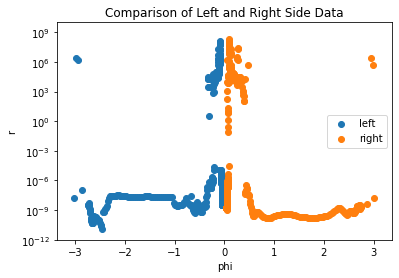

In [35]:
plt.scatter(leftI['phi'],leftI['alpha'],label='left')
plt.scatter(rightI['phi'],rightI['alpha'],label='right')

plt.legend()
plt.xlabel('phi')
plt.ylabel('r')

plt.yscale('log')
plt.ylim(1e-12,1e10)
plt.title('Comparison of Left and Right Side Data')
plt.show()

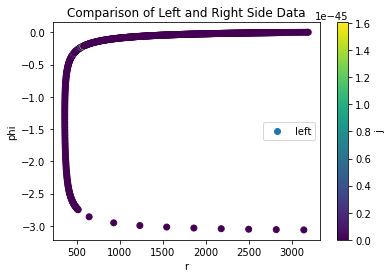

In [59]:
plt.scatter(leftI['r'],leftI['phi'],label='left',c=leftI['j'],cmap='viridis')
#plt.scatter(rightI['r'],rightI['phi'],label='right',c=rightI['j'],norm=LogNorm(vmin=1e-70,vmax=1e-40),cmap='viridis')
plt.colorbar(label='j')
plt.legend()
plt.xlabel('r')
plt.ylabel('phi')

plt.title('Comparison of Left and Right Side Data')
plt.show()

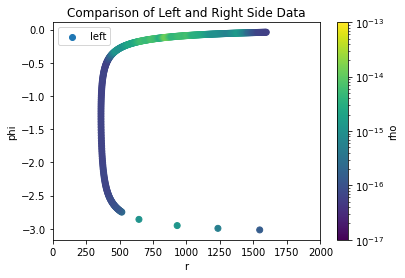

In [63]:
plt.scatter(leftside['r'],leftside['phi'],label='left',c=leftside['rho'],norm=LogNorm(vmin=1e-17,vmax=1e-13),cmap='viridis')
#plt.scatter(rightI['r'],rightI['phi'],label='right',c=rightI['j'],norm=LogNorm(vmin=1e-70,vmax=1e-40),cmap='viridis')
plt.colorbar(label='rho')
plt.legend()
plt.xlabel('r')
plt.ylabel('phi')
plt.xlim(0,2e3)
plt.title('Comparison of Left and Right Side Data')
plt.show()

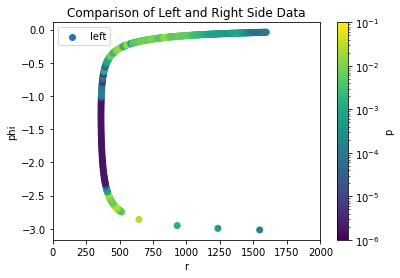

In [81]:
plt.scatter(leftside['r'],leftside['phi'],label='left',c=leftside['p'],norm=LogNorm(vmin=1e-6,vmax=1e-1),cmap='viridis')
#plt.scatter(rightI['r'],rightI['phi'],label='right',c=rightI['j'],norm=LogNorm(vmin=1e-70,vmax=1e-40),cmap='viridis')
plt.colorbar(label='p')
plt.legend()
plt.xlabel('r')
plt.ylabel('phi')
plt.xlim(0,2e3)
plt.title('Comparison of Left and Right Side Data')
plt.show()

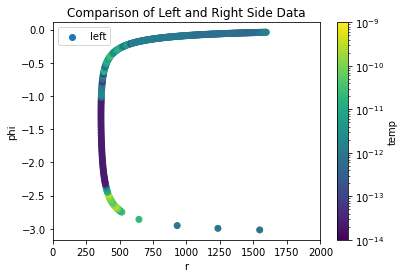

In [83]:
plt.scatter(leftside['r'],leftside['phi'],label='left',c=leftside['temp'],norm=LogNorm(vmin=1e-14,vmax=1e-9),cmap='viridis')
#plt.scatter(rightI['r'],rightI['phi'],label='right',c=rightI['j'],norm=LogNorm(vmin=1e-70,vmax=1e-40),cmap='viridis')
plt.colorbar(label='temp')
plt.legend()
plt.xlabel('r')
plt.ylabel('phi')
plt.xlim(0,2e3)
plt.title('Comparison of Left and Right Side Data')
plt.show()

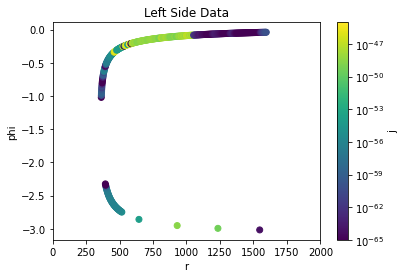

In [88]:
plt.scatter(leftside['r'],leftside['phi'],label='left',c=leftside['j'],norm=LogNorm(vmin=1e-65,vmax=1e-45),cmap='viridis')
#plt.scatter(rightI['r'],rightI['phi'],label='right',c=rightI['j'],norm=LogNorm(vmin=1e-70,vmax=1e-40),cmap='viridis')
plt.colorbar(label='j')
plt.xlabel('r')
plt.ylabel('phi')
plt.xlim(0,2e3)
plt.title('Left Side Data')
plt.show()

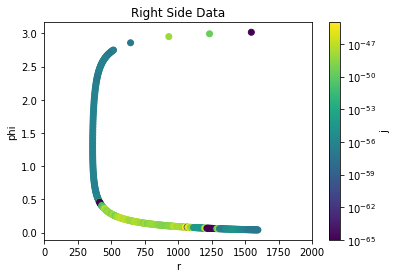

In [89]:
plt.scatter(rightside['r'],rightside['phi'],label='right',c=rightside['j'],norm=LogNorm(vmin=1e-65,vmax=1e-45),cmap='viridis')
#plt.scatter(rightI['r'],rightI['phi'],label='right',c=rightI['j'],norm=LogNorm(vmin=1e-70,vmax=1e-40),cmap='viridis')
plt.colorbar(label='j')
plt.xlabel('r')
plt.ylabel('phi')
plt.xlim(0,2e3)
plt.title('Right Side Data')
plt.show()